<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/Modern_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fundamental setup

In [1]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.optim as optim
from tqdm.auto import tqdm
import torch.nn.functional as F

import random

import matplotlib.pyplot as plt

from scipy.sparse import find

In [2]:
#set seed for reproducibility
random_state = 42

def set_seed(random_state=42):
  random.seed(random_state)
  np.random.seed(random_state)
  torch.manual_seed(random_state)
  torch.cuda.manual_seed_all(random_state)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed()


In [3]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# set project_dir
project_dir = Path('.') / 'drive' / 'MyDrive' / 'AIA_SkinLesion_Projekt'

In [5]:
#path to image data
data_raw =[
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_1'),
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_2'),
    ]

# load metadata
csv_path    = project_dir / 'HAM10000_metadata_converted.csv'
df_metadata = pd.read_csv(csv_path)

#load splits
csv_train = project_dir / 'splits' / 'train.csv'
df_train  = pd.read_csv(csv_train)

csv_train_balanced = project_dir / 'splits' / 'train_balanced.csv'
df_train_balanced  = pd.read_csv(csv_train_balanced)

csv_test = project_dir / 'splits' / 'test.csv'
df_test  = pd.read_csv(csv_test)

csv_val = project_dir / 'splits' / 'val.csv'
df_val  = pd.read_csv(csv_val)

# Data preprocessing for modern pipeline

In [6]:
# EfficientNet-B0 expects 224x224; other resolutions are possible; includes ImageNet normalization

# define image transformations for train and test/validation set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# function for searching images from drive
def find_image_path(img_id, directories):
    img_name = img_id + '.jpg'
    for directory in directories:
        path = os.path.join(directory, img_name)
        if os.path.exists(path):
            return path
    return None

# Dataset class
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = find_image_path(img_id, self.img_dirs)

        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32), img_id

# Use balanced training set if loaded, otherwise use standard df_train
train_set_to_use = df_train_balanced if 'df_train_balanced' in locals() else df_train

# create data sets
train_dataset = SkinDataset(train_set_to_use, data_raw, transform=train_transforms)
val_dataset = SkinDataset(df_val, data_raw, transform=test_transforms)
test_dataset = SkinDataset(df_test, data_raw, transform=test_transforms)

# create data loader
b_size = 32

#reproducibility for DataLoader
g = torch.Generator()
g.manual_seed(random_state)

train_loader = DataLoader(train_dataset, batch_size=b_size, generator=g, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

print(f"Dataset ready. Training uses: {'Balanced Set' if 'df_train_balanced' in locals() else 'Standard Set'}")
print(f"Number of training images: {len(train_dataset)}")

Dataset ready. Training uses: Balanced Set
Number of training images: 2300


Loading original image with id: ISIC_0026610.jpg ...


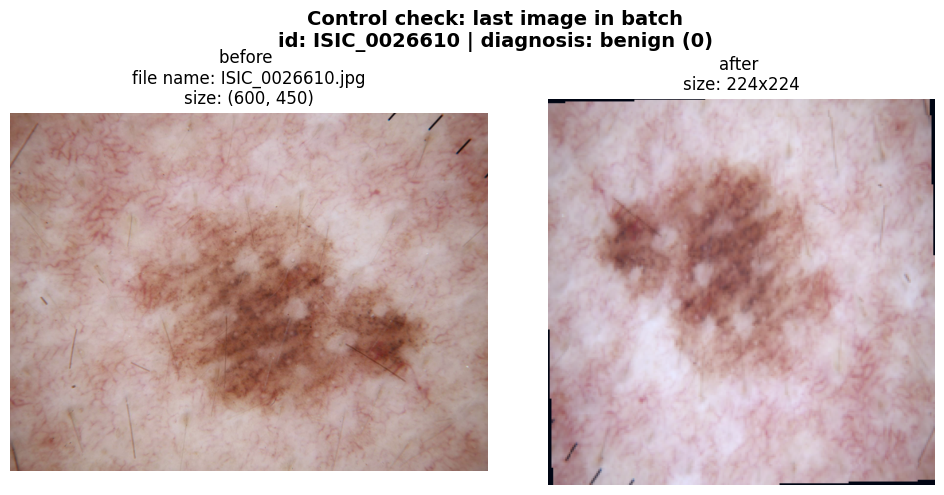

Searched for id: ISIC_0026610
ID from csv:
          image_id  label
8756  ISIC_0026610      0

 Matches csv
finished


In [ ]:
# Example output
images, labels, image_ids = next(iter(train_loader))


tensor_img = images[-1]
label = labels[-1]
last_id = image_ids[-1]

print(f"Loading original image with id: {last_id}.jpg ...")

# image after transformation
img_np = tensor_img.numpy().transpose((1, 2, 0))
#mean = np.array([0.485, 0.456, 0.406])
#std = np.array([0.229, 0.224, 0.225])
#bild_np = std * bild_np + mean
minimum = img_np.min()
maximum = img_np.max()
img_np = (img_np - minimum) / (maximum - minimum)

# original image
img_name = last_id + '.jpg'
original_path = find_image_path(last_id, data_raw)

# show images
if original_path:
    original_image = Image.open(original_path).convert('RGB')
    label_name = "malignant (1)" if label.item() == 1.0 else "benign (0)"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Control check: last image in batch\nid: {last_id} | diagnosis: {label_name}", fontsize=14, fontweight='bold')

    axes[0].imshow(original_image)
    axes[0].set_title(f"before \nfile name: {img_name}\nsize: {original_image.size}", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_np)
    axes[1].set_title(f"after \nsize: {tensor_img.shape[1]}x{tensor_img.shape[2]}", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: {img_name} could not be found!")

check_row = df_metadata[df_metadata['image_id'] == last_id]

print(f"Searched for id: {last_id}")
print(f"ID from csv:\n{check_row[['image_id', 'label']]}")

# additional check
csv_label = check_row['label'].values[0]
batch_label = int(label.item())

if csv_label == batch_label:
    print("\n Matches csv")
else:
    print("\n Differs from csv")

print("finished")


# Modern Pipeline: EfficientNet-B0

In this section, we implement the EfficientNet-B0 model.
- The feature extractor has frozen weights.
- The classification head is adapted for binary classification.
- For uncertainty estimation, we implement a logic for Monte Carlo Dropout.


In [7]:
def get_efficientnet_model(dropout_rate=0.5):
    # Load pre-trained EfficientNet-B0 weights from ImageNet
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    # Freeze backbone: Prevent weights from updating during training
    for param in model.parameters():
        param.requires_grad = False

    # Adapt classification head for binary output (1 neuron)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        # deeper classification head for non linear separating
        nn.Dropout(p=dropout_rate),
        nn.Linear(num_ftrs, 128),
        nn.ReLU(),
        # end deeper classification head
        nn.Dropout(p=dropout_rate),
        nn.Linear(128, 1)
    )

    return model

# Initialize model and move to GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_efficientnet_model()
model = model.to(device)

print(f"Model loaded on {device}.")
# Check trainable params: should only be the new classifier head
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters (head only): {trainable_params}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 225MB/s]


Model loaded on cuda.
Trainable parameters (head only): 164097



### Note on MC Dropout
To measure uncertainty later, we must ensure that Dropout remains active even during the test phase (`model.eval()`). We achieve this by manually setting the Dropout layers back to `.train()`.


In [8]:
def enable_dropout(m):

    # Forces Dropout layers to stay in .train() mode even during evaluation.
    # This allows for Monte Carlo (MC) sampling to estimate uncertainty.

    for module in m.modules():
        if isinstance(module, nn.Dropout):
            module.train()

## Training and Validation with frozen Backbone
We define the loss function (BCEWithLogitsLoss), the optimizer (Adam), and a loop to train and validate the model across several epochs.


In [ ]:
# --- SETTINGS ---
# freshly load model
set_seed()
model = get_efficientnet_model()
model = model.to(device)

num_epochs = 40
learning_rate = 0.001
# TIP: Set limit_batches to 1 for a quick test run. Set to None for full training.
limit_batches = None
save_weights = True # FLAG: Set to True only when you want to export the model file
save_path = project_dir / 'models' / 'efficientnet_skin_model_weights_reproducible.pth'

#for early stopping
patience = 7  # number of epochs without further improvement
min_delta = 0.0 # min value for improvement


# Loss and Optimizer setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate)

# Training Loop
train_losses = []
val_losses = []
train_acc = []
val_acc = []

#for early stopping
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

#start training
print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Regular dropout active; MC Dropout (enable_dropout) not called here
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for i, (images, labels, _) in enumerate(train_loader):
        if limit_batches and i >= limit_batches: break

        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0) #in case last batch is smaller than others
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_correct += (preds == labels).sum().item()

    #epoch_train_loss = running_loss / (len(train_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_correct / total_samples
    train_losses.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for i, (images, labels, _) in enumerate(val_loader):
            if limit_batches and i >= limit_batches: break

            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            preds = (torch.sigmoid(outputs) > 0.5).float()
            running_val_correct += (preds == labels).sum().item()



    epoch_val_loss = running_val_loss / (len(val_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_val_acc = running_val_correct / total_val_samples
    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] completed. "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Check early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  -> new best val loss: {best_val_loss:.4f} (saved model)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping after epoch {epoch+1}. "
                  f"Best Val Loss: {best_val_loss:.4f}")
            break



# Optional Saving
if (save_weights and (best_model_state is not None)):
    #load best model
    model.load_state_dict(best_model_state)
    print("Best model (based on val loss) rebuilt.")

    #save model
    os.makedirs(save_path.parent, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
else:
    print("Run finished! Last weights were kept in RAM only.")

Starting training on cuda...
Epoch [1/40] completed. Train Loss: 0.5640 | Train Acc: 0.7165 | Val Loss: 0.6025 | Val Acc: 0.6691
  -> new best val loss: 0.6025 (saved model)
Epoch [2/40] completed. Train Loss: 0.5115 | Train Acc: 0.7478 | Val Loss: 0.4931 | Val Acc: 0.7232
  -> new best val loss: 0.4931 (saved model)
Epoch [3/40] completed. Train Loss: 0.4907 | Train Acc: 0.7596 | Val Loss: 0.4403 | Val Acc: 0.7722
  -> new best val loss: 0.4403 (saved model)
Epoch [4/40] completed. Train Loss: 0.4962 | Train Acc: 0.7596 | Val Loss: 0.4412 | Val Acc: 0.7651
  -> No improvement for 1 epochs.
Epoch [5/40] completed. Train Loss: 0.4748 | Train Acc: 0.7700 | Val Loss: 0.4814 | Val Acc: 0.7130
  -> No improvement for 2 epochs.
Epoch [6/40] completed. Train Loss: 0.4718 | Train Acc: 0.7743 | Val Loss: 0.5082 | Val Acc: 0.7007
  -> No improvement for 3 epochs.
Epoch [7/40] completed. Train Loss: 0.4676 | Train Acc: 0.7713 | Val Loss: 0.4738 | Val Acc: 0.7120
  -> No improvement for 4 epochs.


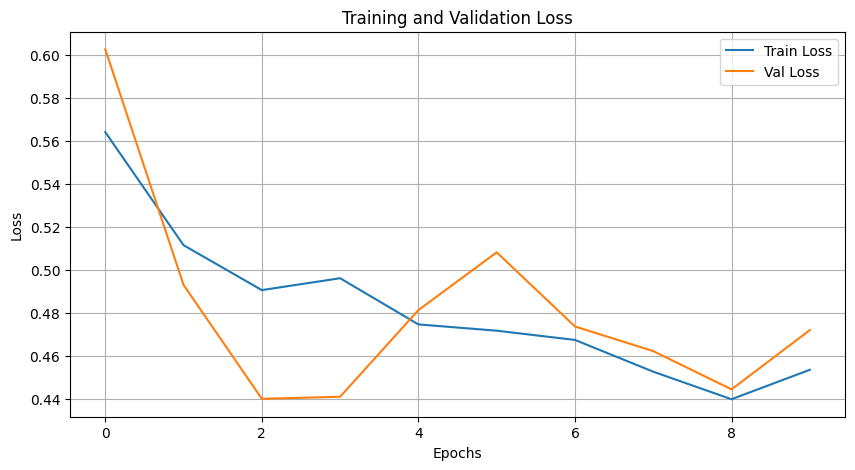

In [ ]:
# Visualize training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Training with Unfrozen backbone

In [ ]:
#freshly load model
set_seed()
model = get_efficientnet_model()
model = model.to(device)
unfreeze_backbone = True #used in test set

# unfreeze backbone
layers_to_unfreeze = ["features.7", "features.8", "classifier"]  #for unfreezing more layer


for name, param in model.named_parameters():
    if any(x in name for x in layers_to_unfreeze):
        param.requires_grad = True
    else:
        param.requires_grad = False

# --- SETTINGS --- duplicated from frozen backbone

num_epochs = 40
learning_rate = 0.0001
# TIP: Set limit_batches to 1 for a quick test run. Set to None for full training.
limit_batches = None
save_weights = True # FLAG: Set to True only when you want to export the model file
save_path = project_dir / 'models' / 'efficientnet_finetuned_backbone_reproducible.pth'

#for early stopping
patience = 7  # number of epochs without further improvement
min_delta = 0.0 #min value for improvement

# Loss and Optimizer setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)  #adapted for unfrozen pipeline

# Training Loop
train_losses = []
val_losses = []
train_acc = []
val_acc = []

#for early stopping
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

#start training
print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Regular dropout active; MC Dropout (enable_dropout) not called here
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for i, (images, labels, _) in enumerate(train_loader):
        if limit_batches and i >= limit_batches: break

        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0) #in case last batch is smaller than others
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_correct += (preds == labels).sum().item()

    #epoch_train_loss = running_loss / (len(train_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_correct / total_samples
    train_losses.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for i, (images, labels, _) in enumerate(val_loader):
            if limit_batches and i >= limit_batches: break

            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            preds = (torch.sigmoid(outputs) > 0.5).float()
            running_val_correct += (preds == labels).sum().item()



    epoch_val_loss = running_val_loss / (len(val_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_val_acc = running_val_correct / total_val_samples
    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] completed. "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Check early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  -> new best val loss: {best_val_loss:.4f} (saved model)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping after epoch {epoch+1}. "
                  f"Best Val Loss: {best_val_loss:.4f}")
            break



# Optional Saving
if (save_weights and (best_model_state is not None)):
    #load best model
    model.load_state_dict(best_model_state)
    print("Best model (based on val loss) rebuilt.")

    #save model
    os.makedirs(save_path.parent, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
else:
    print("Run finished! Last weights were kept in RAM only.")

Starting training on cuda...
Epoch [1/40] completed. Train Loss: 0.6415 | Train Acc: 0.6700 | Val Loss: 0.6185 | Val Acc: 0.6609
  -> new best val loss: 0.6185 (saved model)
Epoch [2/40] completed. Train Loss: 0.5214 | Train Acc: 0.7574 | Val Loss: 0.5337 | Val Acc: 0.6874
  -> new best val loss: 0.5337 (saved model)
Epoch [3/40] completed. Train Loss: 0.4599 | Train Acc: 0.7730 | Val Loss: 0.4905 | Val Acc: 0.7211
  -> new best val loss: 0.4905 (saved model)
Epoch [4/40] completed. Train Loss: 0.4445 | Train Acc: 0.7765 | Val Loss: 0.4576 | Val Acc: 0.7416
  -> new best val loss: 0.4576 (saved model)
Epoch [5/40] completed. Train Loss: 0.4362 | Train Acc: 0.7765 | Val Loss: 0.4751 | Val Acc: 0.7354
  -> No improvement for 1 epochs.
Epoch [6/40] completed. Train Loss: 0.4236 | Train Acc: 0.7891 | Val Loss: 0.4848 | Val Acc: 0.7334
  -> No improvement for 2 epochs.
Epoch [7/40] completed. Train Loss: 0.4130 | Train Acc: 0.8004 | Val Loss: 0.4735 | Val Acc: 0.7508
  -> No improvement for

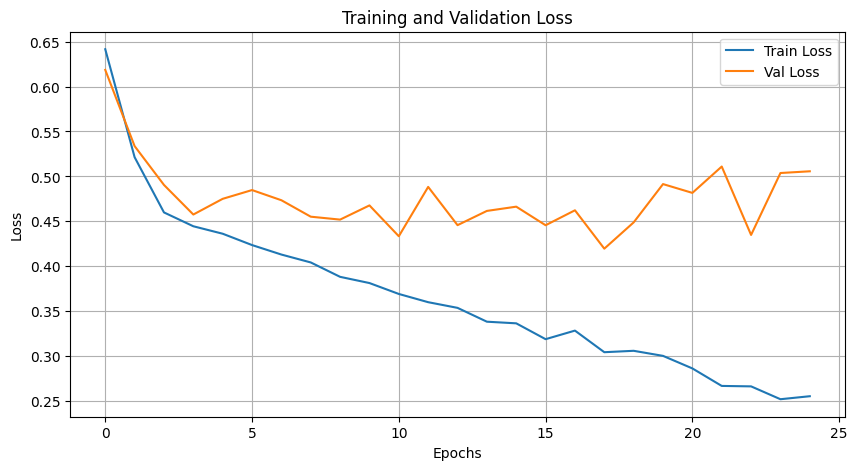

In [ ]:
# Visualize training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Loading Saved Weights


In [9]:
# Define file path
#weights_path = project_dir / 'models' / 'efficientnet_skin_model_weights_reproducible.pth'
# weights with unfrozen backbone
weights_path = project_dir / 'models' / 'efficientnet_finetuned_backbone_reproducible.pth'

# Check if file exists
if weights_path.exists():
    # Load the weights (state_dict)
    # map_location='cpu' allows loading even without a GPU
    state_dict = torch.load(weights_path, map_location=device)

    # Transfer weights into the model
    model.load_state_dict(state_dict)
    model.to(device)

    print(f"Weights successfully loaded from {weights_path}.")
else:
    print(f"No weight file found at {weights_path}. Did you use 'save_weights = True' during training?")

Weights successfully loaded from drive/MyDrive/AIA_SkinLesion_Projekt/models/efficientnet_finetuned_backbone_reproducible.pth.


In [10]:


def predict_with_uncertainty(model, dataloader, num_samples=10):
    """ Performs MC Dropout by running multiple forward passes """
    model.eval()
    enable_dropout(model) # Keep Dropout active

    images, labels, ids = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        # Collect predictions from multiple passes
        outputs = torch.stack([model(images) for _ in range(num_samples)])
        probs = torch.sigmoid(outputs)

    mean_probs = probs.mean(dim=0).cpu().numpy()
    std_probs = probs.std(dim=0).cpu().numpy()

    return images.cpu(), labels.numpy(), mean_probs, std_probs, ids

# --- Demonstration ---
imgs, lbls, means, stds, img_ids = predict_with_uncertainty(model, val_loader)

idx = 0
print(f"Image ID: {img_ids[idx]}")
print(f"True Label: {'Malignant' if lbls[idx] == 1 else 'Benign'}")
print(f"Model Prediction (Mean Prob): {means[idx][0]:.4f}")
print(f"Uncertainty (Std Dev): {stds[idx][0]:.4f}")

Image ID: ISIC_0029176
True Label: Benign
Model Prediction (Mean Prob): 0.5624
Uncertainty (Std Dev): 0.0423


#### precision & recall on the Val set

In [12]:

def evaluate_with_uncertainty(model, dataloader, num_samples=10):
    #  Performs MC Dropout over the full dataloader and computes
    #  precision/recall alongside mean predictions and uncertainty.
    model.eval()
    enable_dropout(model)  # Keep Dropout active

    all_means = []
    all_stds = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for images, labels, ids in dataloader:
            images = images.to(device)

            # Collect predictions from multiple stochastic passes
            outputs = torch.stack([model(images) for _ in range(num_samples)])
            probs = torch.sigmoid(outputs)

            mean_probs = probs.mean(dim=0).cpu().numpy()
            std_probs = probs.std(dim=0).cpu().numpy()

            all_means.append(mean_probs)
            all_stds.append(std_probs)
            all_labels.append(labels.numpy())
            all_ids.extend(ids)

    all_means = np.concatenate(all_means, axis=0)
    all_stds = np.concatenate(all_stds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_means, all_stds, all_labels, all_ids


def compute_precision_recall(mean_probs, true_labels, threshold=0.5):
    # Computes precision and recall for binary classification.
    preds = (mean_probs.squeeze() > threshold).astype(int)
    labels = true_labels.astype(int)

    true_positives = ((preds == 1) & (labels == 1)).sum()
    false_positives = ((preds == 1) & (labels == 0)).sum()
    false_negatives = ((preds == 0) & (labels == 1)).sum()

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0

    return precision, recall


# --- Demonstration ---
means, stds, labels, img_ids = evaluate_with_uncertainty(model, val_loader)

precision, recall = compute_precision_recall(means, labels)
print(f"Validation Precision (False Positives): {precision:.4f}")
print(f"Validation Recall (Detection rate malignant): {recall:.4f}")

# sample
idx = 0
print(f"\nImage ID: {img_ids[idx]}")
print(f"True Label: {'Malignant' if labels[idx] == 1 else 'Benign'}")
print(f"Model Prediction (Mean Prob): {means[idx][0]:.4f}")
print(f"Uncertainty (Std Dev): {stds[idx][0]:.4f}")

Validation Precision (False Positives): 0.4746
Validation Recall (Detection rate malignant): 0.7988

Image ID: ISIC_0029176
True Label: Benign
Model Prediction (Mean Prob): 0.5640
Uncertainty (Std Dev): 0.0652


In [13]:


test_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for t in test_thresholds:
    p, r = compute_precision_recall(means, labels, threshold=t)
    results.append({
        'Threshold': t,
        'Precision': f"{p:.2%}",
        'Recall': f"{r:.2%}"
    })

df_thresholds_clean = pd.DataFrame(results)
display(df_thresholds_clean)

,Threshold,Precision,Recall
0,0.1,30.65%,97.56%
1,0.2,35.94%,95.12%
2,0.3,39.79%,91.46%
3,0.4,42.47%,85.98%
4,0.5,47.46%,79.88%
5,0.6,53.24%,70.12%
6,0.7,54.40%,60.37%
7,0.8,53.47%,46.95%
8,0.9,64.20%,31.71%


## Alternative Approach: Standard Test Set Evaluation

In [14]:
def evaluate_test_set(model, dataloader):
    model.eval()
    # Note: We do NOT use enable_dropout here for the standard 'final' performance

    all_preds = []
    all_labels = []

    print(f"Starting Test Set Evaluation...")

    with torch.no_grad():
        for i, (images, labels, _) in enumerate(dataloader):
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

            if (i + 1) % 10 == 0:
                print(f"Batch {i+1}/{len(dataloader)} processed...")

    return np.array(all_labels), np.array(all_preds)

# Run evaluation
#labels_test, preds_test = evaluate_test_set(model, test_loader)
#print("Evaluation finished.")

### MC Dropout Evaluation on Test Set
This cell applies MC Dropout to the entire Test Set to get uncertainty estimates for every final prediction.

In [15]:
def evaluate_test_set_with_uncertainty(model, dataloader, num_samples=10):
    model.eval()
    enable_dropout(model) # Ensure Dropout stays active

    all_means = []
    all_stds = []
    all_labels = []
    all_ids = []

    print(f"Starts MC Dropout Evaluation ({num_samples} runs per image)... ")

    with torch.no_grad():
        for i, (images, labels, ids) in enumerate(dataloader):
            images = images.to(device)

            # Multiple forward passes
            outputs = torch.stack([model(images) for _ in range(num_samples)])
            probs = torch.sigmoid(outputs)

            mean_probs = probs.mean(dim=0).cpu().numpy()
            std_probs = probs.std(dim=0).cpu().numpy()

            all_means.extend(mean_probs)
            all_stds.extend(std_probs)
            all_labels.extend(labels.numpy())
            all_ids.extend(ids)

            # Text-basiertes Log alle 10 Batches statt tqdm-Ladebalken
            if (i + 1) % 10 == 0:
                print(f"Batch {i+1}/{len(dataloader)} processed...")

    return np.array(all_ids), np.array(all_labels), np.array(all_means), np.array(all_stds)

## Final Procedure: Test Set Evaluation

In [20]:
# Set file names based on the mode
#suffix = "unfrozen" if (locals().get('unfreeze_backbone', False)) else "frozen"
suffix = "unfrozen"
filename = f'final_test_results_{suffix}_backbone_modern.csv'
output_path = project_dir / filename

print(f"--- Finale Test-Evaluation ({suffix.upper()}) ---")

#  Run the evaluation
test_ids, test_labels, test_means, test_stds = evaluate_test_set_with_uncertainty(model, test_loader, num_samples=20)

# DataFrame created
results_df = pd.DataFrame({
    'image_id': test_ids,
    'true_label': test_labels,
    'prediction_prob': test_means.flatten(),
    'uncertainty_std': test_stds.flatten()
})

# display and save
display(results_df.head())
results_df.to_csv(output_path, index=False)
print(f"\n Results saved: {output_path}")

--- Finale Test-Evaluation (UNFROZEN) ---
Starts MC Dropout Evaluation (20 runs per image)... 
Batch 10/60 processed...
Batch 20/60 processed...
Batch 30/60 processed...
Batch 40/60 processed...
Batch 50/60 processed...
Batch 60/60 processed...


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.437568,0.168790
1,ISIC_0027310,0.0,0.270461,0.069388
2,ISIC_0032128,0.0,0.203619,0.064615
3,ISIC_0025937,0.0,0.424584,0.133523
4,ISIC_0031753,0.0,0.263165,0.077857



###  Load Existing Test Results



In [16]:
# Configure execution parameters: Select the experiment configuration to be loaded
load_suffix = "frozen"  # Options: "frozen" or "unfrozen"
load_path = project_dir / f'final_test_results_{load_suffix}_backbone_modern.csv'

if load_path.exists():
    results_frozen_df = pd.read_csv(load_path)
    print(f"Success: Inference results successfully retrieved from storage: {load_path}")
    display(results_frozen_df.head())
else:
    print(f"Error: Specified file not found: {load_path}.")

# Configure execution parameters: Select the alternative experiment configuration
load_suffix = "unfrozen"  # Options: "frozen" or "unfrozen"
load_path = project_dir / f'final_test_results_{load_suffix}_backbone_modern.csv'

if load_path.exists():
    results_unfrozen_df = pd.read_csv(load_path)
    print(f"Success: Inference results successfully retrieved from storage: {load_path}")
    display(results_unfrozen_df.head())
else:
    print(f"Error: Specified file not found: {load_path}.")

Success: Inference results successfully retrieved from storage: drive/MyDrive/AIA_SkinLesion_Projekt/final_test_results_frozen_backbone_modern.csv


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.564331,0.161961
1,ISIC_0027310,0.0,0.604871,0.125986
2,ISIC_0032128,0.0,0.544099,0.081000
3,ISIC_0025937,0.0,0.618529,0.089964
4,ISIC_0031753,0.0,0.622998,0.105303


Success: Inference results successfully retrieved from storage: drive/MyDrive/AIA_SkinLesion_Projekt/final_test_results_unfrozen_backbone_modern.csv


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.403891,0.132279
1,ISIC_0027310,0.0,0.265650,0.070511
2,ISIC_0032128,0.0,0.214581,0.069675
3,ISIC_0025937,0.0,0.408551,0.124921
4,ISIC_0031753,0.0,0.268260,0.079188


In [17]:

# Define the decision threshold (empirically determined as optimal during the validation phase)
test_threshold = 0.3  # Target values: 0.3

# Compute evaluation metrics for the frozen backbone configuration
preds_test = (results_frozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_frozen_df['true_label'].astype(int)

tp = ((preds_test == 1) & (labels_test == 1)).sum()
fp = ((preds_test == 1) & (labels_test == 0)).sum()
fn = ((preds_test == 0) & (labels_test == 1)).sum()
tn = ((preds_test == 0) & (labels_test == 0)).sum()

test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
test_accuracy = (tp + tn) / len(results_frozen_df)

print(f"--- Evaluation Metrics: Frozen Backbone (Decision Threshold: {test_threshold}) ---")
print(f"Precision: {test_precision:.2%}")
print(f"Recall:    {test_recall:.2%}")
print(f"Accuracy:  {test_accuracy:.2%}")
print(f"\nSummary: The model successfully identifies {test_recall:.2%} of the malignant lesions within the test cohort.\n")

# Compute evaluation metrics for the unfrozen backbone configuration
preds_test = (results_unfrozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_unfrozen_df['true_label'].astype(int)

tp = ((preds_test == 1) & (labels_test == 1)).sum()
fp = ((preds_test == 1) & (labels_test == 0)).sum()
fn = ((preds_test == 0) & (labels_test == 1)).sum()
tn = ((preds_test == 0) & (labels_test == 0)).sum()

test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
test_accuracy = (tp + tn) / len(results_unfrozen_df)

print(f"--- Evaluation Metrics: Unfrozen Backbone (Decision Threshold: {test_threshold}) ---")
print(f"Precision: {test_precision:.2%}")
print(f"Recall:    {test_recall:.2%}")
print(f"Accuracy:  {test_accuracy:.2%}")
print(f"\nSummary: The model successfully identifies {test_recall:.2%} of the malignant lesions within the test cohort.")

--- Evaluation Metrics: Frozen Backbone (Decision Threshold: 0.3) ---
Precision: 28.75%
Recall:    96.81%
Accuracy:  60.30%

Summary: The model successfully identifies 96.81% of the malignant lesions within the test cohort.

--- Evaluation Metrics: Unfrozen Backbone (Decision Threshold: 0.3) ---
Precision: 37.65%
Recall:    90.10%
Accuracy:  74.02%

Summary: The model successfully identifies 90.10% of the malignant lesions within the test cohort.


### Confusion Matrix

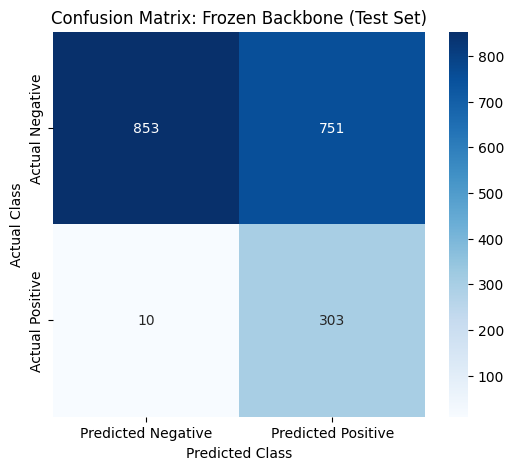

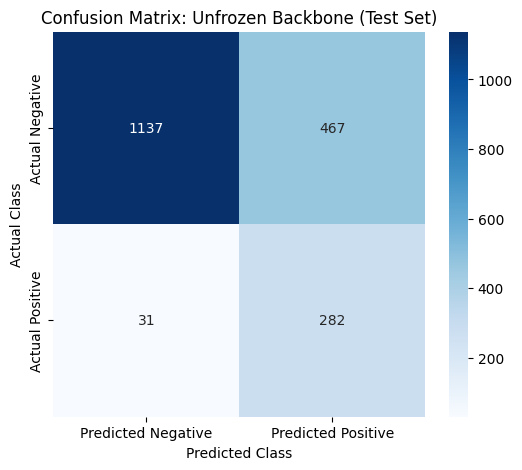

In [18]:

# Generate predictions based on the predefined threshold for the frozen backbone
preds_test = (results_frozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_frozen_df['true_label'].astype(int)

# Compute the confusion matrix
cm_frozen = confusion_matrix(labels_test, preds_test)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix: Frozen Backbone (Test Set)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Generate predictions based on the predefined threshold for the unfrozen backbone
preds_test = (results_unfrozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_unfrozen_df['true_label'].astype(int)

# Compute the confusion matrix
cm_unfrozen = confusion_matrix(labels_test, preds_test)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_unfrozen, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix: Unfrozen Backbone (Test Set)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

### ROC-Kurve und AUC

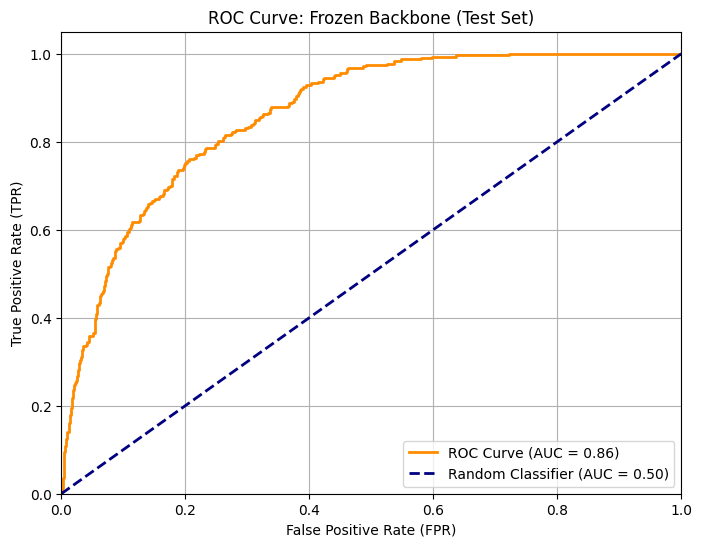

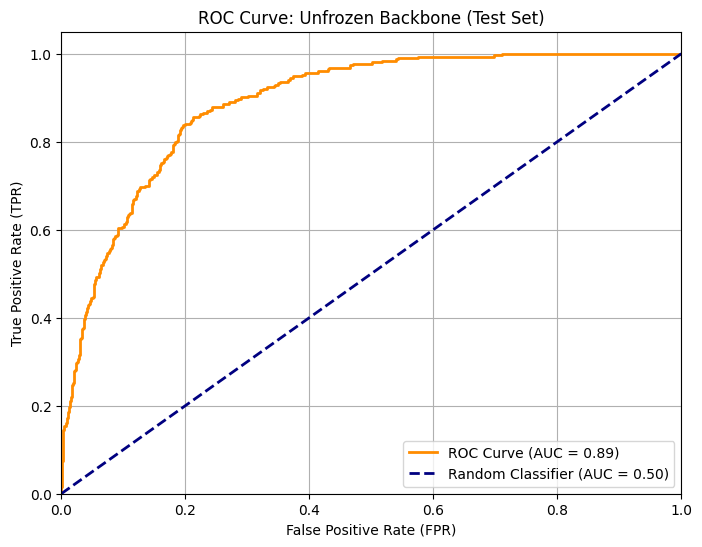

In [19]:

# --- ROC Curve: Frozen Backbone ---

# Extract ground truth labels and prediction probabilities
labels_test_frozen = results_frozen_df['true_label'].astype(int)
probs_test_frozen = results_frozen_df['prediction_prob']

# Compute Receiver Operating Characteristic (ROC) metrics and Area Under the Curve (AUC)
fpr_frozen, tpr_frozen, thresholds_frozen = roc_curve(labels_test_frozen, probs_test_frozen)
roc_auc_frozen = auc(fpr_frozen, tpr_frozen)

# Visualize the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_frozen, tpr_frozen, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_frozen:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Frozen Backbone (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# --- ROC Curve: Unfrozen Backbone ---

# Extract ground truth labels and prediction probabilities
labels_test_unfrozen = results_unfrozen_df['true_label'].astype(int)
probs_test_unfrozen = results_unfrozen_df['prediction_prob']

# Compute Receiver Operating Characteristic (ROC) metrics and Area Under the Curve (AUC)
fpr_unfrozen, tpr_unfrozen, thresholds_unfrozen = roc_curve(labels_test_unfrozen, probs_test_unfrozen)
roc_auc_unfrozen = auc(fpr_unfrozen, tpr_unfrozen)

# Visualize the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_unfrozen, tpr_unfrozen, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_unfrozen:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Unfrozen Backbone (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### High-Resolution Visualization Export
This section defines the export utility and generates high-resolution (300 DPI) image files for the Confusion Matrices and ROC Curves.

In [21]:
def export_visualization(fig, filename):
    #Utility to export figures in 300 DPI to the project directory.
    export_path = project_dir / 'exports' / 'figures'
    os.makedirs(export_path, exist_ok=True)
    full_path = export_path / f"{filename}.png"
    fig.savefig(full_path, dpi=300, bbox_inches='tight')
    print(f"Exported: {full_path}")

# Confusion Matrix: Frozen Backbone
fig1 = plt.figure(figsize=(6, 5))
sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix: Frozen Backbone')
export_visualization(fig1, 'confusion_matrix_frozen')
plt.close(fig1)

# Confusion Matrix: Unfrozen Backbone
fig2 = plt.figure(figsize=(6, 5))
sns.heatmap(cm_unfrozen, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix: Unfrozen Backbone')
export_visualization(fig2, 'confusion_matrix_unfrozen')
plt.close(fig2)

Exported: drive/MyDrive/AIA_SkinLesion_Projekt/exports/figures/confusion_matrix_frozen.png
Exported: drive/MyDrive/AIA_SkinLesion_Projekt/exports/figures/confusion_matrix_unfrozen.png


Exported: drive/MyDrive/AIA_SkinLesion_Projekt/exports/figures/roc_curve_frozen.png


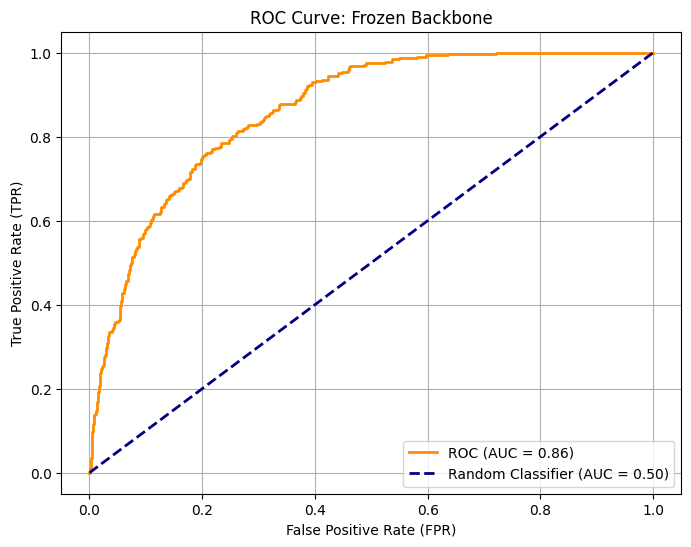

Exported: drive/MyDrive/AIA_SkinLesion_Projekt/exports/figures/roc_curve_unfrozen.png


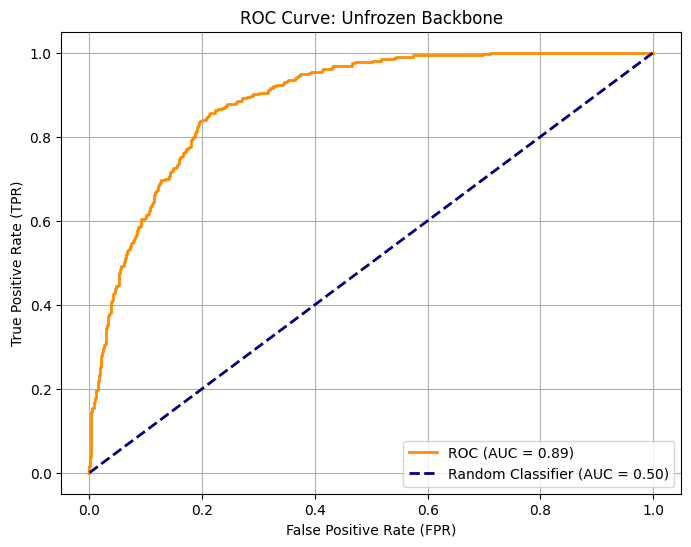

In [23]:
# ROC Curve: Frozen Backbone
fig3 = plt.figure(figsize=(8, 6))
plt.plot(fpr_frozen, tpr_frozen, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_frozen:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Frozen Backbone')
plt.legend(loc='lower right')
plt.grid(True)
export_visualization(fig3, 'roc_curve_frozen')
plt.show()

# ROC Curve: Unfrozen Backbone
fig4 = plt.figure(figsize=(8, 6))
plt.plot(fpr_unfrozen, tpr_unfrozen, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_unfrozen:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Unfrozen Backbone')
plt.legend(loc='lower right')
plt.grid(True)
export_visualization(fig4, 'roc_curve_unfrozen')
plt.show()